# 🧠 LABORATORIO N° 10 — Minería de Datos

## Redes Neuronales Artificiales
## Detección de Fraude con Credit Card Fraud Detection

| | |
|---|---|
| **Curso** | Minería de Datos — C64893 |
| **Semana** | 10 |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Institución** | TECSUP — Pasión por la Tecnología |
| **Semestre** | 2026-I |

---
## 📋 Instrucciones generales
- Ejecuta **todas** las celdas de código en orden.
- Responde las preguntas en las celdas Markdown asignadas.
- No modifiques el código guía a menos que se indique explícitamente.
- Al finalizar, descarga el notebook `.ipynb` con todas las celdas ejecutadas.

## 📚 Referencias de la sesión
- Géron, A. (2023). *Hands-On Machine Learning* (3.ª ed.). O'Reilly. Cap. 10–11.
- Goodfellow, I., Bengio, Y., y Courville, A. (2016). *Deep Learning*. MIT Press. Cap. 6.
- Gironés Roig, J. et al. (2017). *Minería de datos: modelos y algoritmos*. UOC. Cap. 7.
- Burkov, A. (2019). *The Hundred-Page Machine Learning Book*. Cap. 6.
---

---
# ACTIVIDAD 1: Revisión de Conceptos — Redes Neuronales Artificiales

Complete la siguiente tabla con definiciones propias. **No copie textualmente** de los materiales.

| N° | Concepto / Principio | Definición con sus propias palabras |
|:--:|:---|:---|
| 1 | Neurona artificial | Unidad básica de una RNA que recibe entradas ponderadas, las suma y aplica una función de activación para producir una salida. Imita el funcionamiento de una neurona biológica. |
| 2 | Función de activación | Función matemática no lineal aplicada a la salida de una neurona para introducir no linealidad en la red, permitiendo aprender patrones complejos (ej: ReLU, Sigmoid, Tanh). |
| 3 | ReLU (Rectified Linear Unit) | f(x) = max(0, x). Devuelve 0 si la entrada es negativa y la entrada misma si es positiva. Es la función de activación más usada en capas ocultas por ser computacionalmente eficiente y reducir el problema del gradiente desvaneciente. |
| 4 | Backpropagation | Algoritmo de retropropagación del error: calcula el gradiente de la función de pérdida respecto a cada peso propagando el error desde la capa de salida hacia las capas anteriores usando la regla de la cadena. |
| 5 | Descenso de gradiente (SGD) | Algoritmo de optimización que actualiza los pesos en la dirección opuesta al gradiente de la pérdida, reduciendo iterativamente el error. SGD usa un solo ejemplo (o mini-batch) por actualización, haciendo el proceso más rápido que el gradiente batch completo. |
| 6 | Optimizador Adam | Optimizador adaptativo que combina momentum (memoria del gradiente pasado) y RMSprop (tasa de aprendizaje adaptativa por parámetro). Converge más rápido que SGD puro y requiere menos ajuste manual del learning rate. |
| 7 | Learning rate (tasa de aprendizaje) | Hiperparámetro que controla el tamaño del paso en cada actualización de pesos. Muy alto → divergencia (el modelo no converge); muy bajo → convergencia lenta o atasco en mínimos locales. Típicamente entre 0.001 y 0.01. |
| 8 | Época (Epoch) | Un recorrido completo de todos los datos de entrenamiento a través de la red. En cada epoch se actualiza los pesos con backpropagation. Se monitorea la pérdida en validación para detectar overfitting. |
| 9 | Overfitting en redes neuronales | Fenómeno donde la red memoriza el training set en lugar de generalizar: la pérdida en training sigue bajando pero la pérdida en validación aumenta. Se combate con Dropout, regularización L1/L2, Early Stopping y más datos. |
| 10 | Dropout | Técnica de regularización que desactiva aleatoriamente una fracción de neuronas durante el entrenamiento (ej: 0.3 = 30% de neuronas se ponen a 0). Fuerza a la red a aprender representaciones redundantes y robustas, reduciendo la dependencia entre neuronas. |
| 11 | Regularización L1 / L2 | L1 (Lasso): agrega la suma de valores absolutos de los pesos a la pérdida → induce sparsity (pesos→0). L2 (Ridge): agrega la suma de cuadrados → penaliza pesos grandes uniformemente. Ambas reducen overfitting limitando la magnitud de los pesos. |
| 12 | ¿Por qué AUC-ROC es más adecuado que Accuracy para datos desbalanceados? | *(escribe aquí)* |

📌 *Referencia: Géron, A. (2023). Cap. 10–11. | Goodfellow et al. (2016). Deep Learning. MIT Press. Cap. 6.*

---

---
# ACTIVIDAD 2: Desarrollo Práctico — Red Neuronal para Detección de Fraude

En esta actividad construirás una red neuronal con **Keras/TensorFlow** para detectar transacciones fraudulentas en el dataset Credit Card Fraud Detection. Seguirás la metodología **CRISP-DM** paso a paso.

📌 *Referencia general: Géron, A. (2023). Hands-On Machine Learning. O'Reilly. Cap. 10.*

---

## ◆ Paso 1: Instalación e importación de librerías

Instalamos las librerías necesarias e importamos todos los módulos. Fijamos la semilla global para reproducibilidad.



In [ ]:
# !pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_score,
                             recall_score, f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print(f"✅ TensorFlow {tf.__version__} cargado correctamente.")

✅ TensorFlow 2.20.0 cargado correctamente.


### ✏ Pregunta 1
**¿Por qué es importante fijar una semilla global en experimentos con redes neuronales? ¿Qué partes del proceso están sujetas a aleatoriedad en Keras/TensorFlow?**

**Respuesta:** Fijar una semilla global (`random_state`, `np.random.seed`, `tf.random.set_seed`) garantiza la **reproducibilidad**: que el experimento produzca los mismos resultados al reejecutarse. En Keras/TensorFlow las fuentes de aleatoriedad son: inicialización de pesos (Xavier/He), selección de mini-batches en SGD, operaciones de Dropout, y el orden de los datos en cada epoch. Sin semilla fija, dos ejecuciones del mismo código pueden dar métricas diferentes.

---
## ◆ Paso 2: Carga del dataset

Cargamos el **Credit Card Fraud Detection** dataset. Contiene 284,807 transacciones reales (septiembre 2013), de las cuales solo **492 son fraudes** (0.172%). Las variables V1–V28 son componentes PCA anonimizadas.

📌 *Referencia: Gironés Roig, J. et al. (2017). UOC. Cap. 1.*

In [ ]:
# Opción A: Kaggle API (requiere credenciales)
# !kaggle datasets download -d mlg-ulb/creditcardfraud --unzip

# Opción B: URL pública de respaldo
url = ('https://raw.githubusercontent.com/nsethi31/'
       'Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv')
try:
    df = pd.read_csv(url)
    print("✅ Dataset cargado desde URL pública.")
except Exception as e:
    print(f"⚠ URL no disponible ({e}). Generando dataset sintético...")
    from sklearn.datasets import make_classification
    X_s, y_s = make_classification(n_samples=10000, n_features=29,
                                    n_informative=20, weights=[0.998, 0.002],
                                    random_state=SEED)
    cols = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount', 'Class']
    df = pd.DataFrame(np.column_stack([np.arange(10000), X_s, y_s]), columns=cols)
    df['Class'] = df['Class'].astype(int)
    print("⚠ Usando dataset sintético (misma estructura que el original).")

print(f"\n📦 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n🎯 Distribución de clases:")
print(df['Class'].value_counts())
print(f"   Tasa de fraude: {df['Class'].mean()*100:.4f}%")
df.head()

✅ Dataset cargado desde URL pública.

📦 Dimensiones: 284,807 filas × 31 columnas

🎯 Distribución de clases:
Class
0    284315
1       492
Name: count, dtype: int64
   Tasa de fraude: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### ✏ Pregunta 2
**¿Por qué las variables V1–V28 ya vienen transformadas mediante PCA? ¿Qué ventajas tiene esto desde el punto de vista de la privacidad de los datos? ¿Qué información se pierde con esta transformación?**

**Respuesta:** Las variables V1–V28 ya vienen transformadas con PCA por razones de **privacidad**: PCA oculta las características originales de las transacciones (comercio, tarjeta, tipo de transacción), protegiendo datos sensibles de titulares de tarjetas. La información que se pierde es la interpretabilidad directa: no podemos saber qué representa V1 o V14 en términos de negocio. Solo Amount y Time conservan su escala original.

---
## ◆ Paso 3: Exploración inicial

Analizamos la distribución del dataset, el severo desbalance de clases y las diferencias entre transacciones legítimas y fraudulentas.

DISTRIBUCIÓN DE CLASES
  Legítimas (0): 284,315  (99.827%)
  Fraudes   (1):     492  (0.173%)
  Ratio desbalance: 578:1


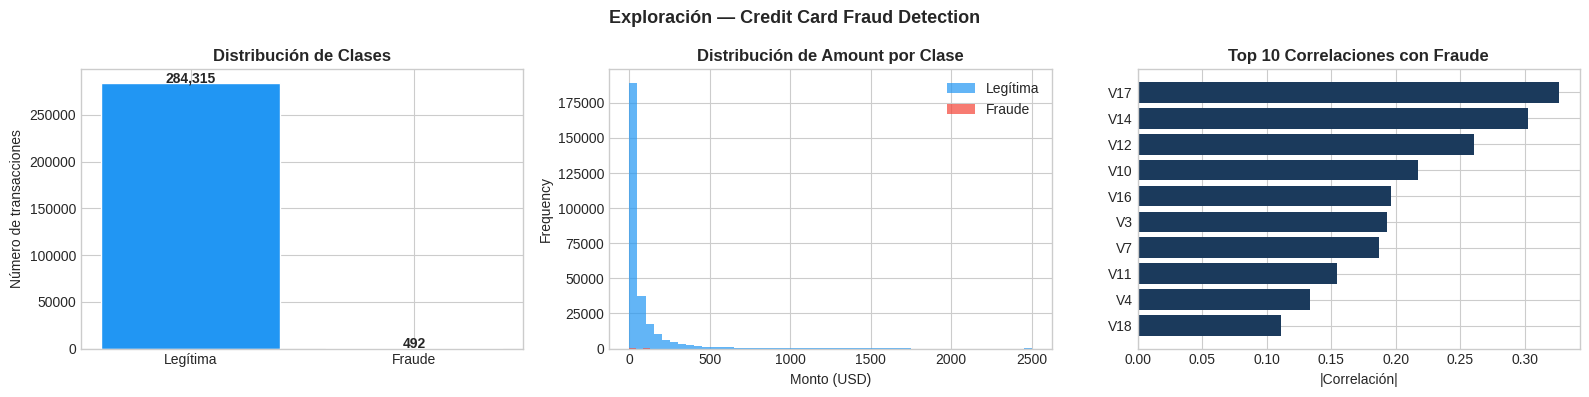


📊 Amount — Fraudes:    media=122.21, max=2125.87
📊 Amount — Legítimas:  media=88.29, max=25691.16


In [ ]:
counts = df['Class'].value_counts()
pct    = df['Class'].value_counts(normalize=True) * 100

print('='*55)
print('DISTRIBUCIÓN DE CLASES')
print('='*55)
print(f"  Legítimas (0): {counts[0]:>7,}  ({pct[0]:.3f}%)")
print(f"  Fraudes   (1): {counts[1]:>7,}  ({pct[1]:.3f}%)")
print(f"  Ratio desbalance: {counts[0]/counts[1]:.0f}:1")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución de clases
axes[0].bar(['Legítima', 'Fraude'], counts, color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Distribución de Clases', fontweight='bold')
axes[0].set_ylabel('Número de transacciones')
for bar, val in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Amount por clase
df[df['Class']==0]['Amount'].clip(0, 2500).plot.hist(
    ax=axes[1], bins=50, alpha=0.7, color='#2196F3', label='Legítima')
df[df['Class']==1]['Amount'].plot.hist(
    ax=axes[1], bins=50, alpha=0.7, color='#F44336', label='Fraude')
axes[1].set_title('Distribución de Amount por Clase', fontweight='bold')
axes[1].set_xlabel('Monto (USD)'); axes[1].legend()

# Correlaciones con clase
corrs = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(10)
axes[2].barh(corrs.index[::-1], corrs.values[::-1], color='#1B3A5C')
axes[2].set_title('Top 10 Correlaciones con Fraude', fontweight='bold')
axes[2].set_xlabel('|Correlación|')

plt.suptitle('Exploración — Credit Card Fraud Detection', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n📊 Amount — Fraudes:    media={df[df['Class']==1]['Amount'].mean():.2f}, max={df[df['Class']==1]['Amount'].max():.2f}")
print(f"📊 Amount — Legítimas:  media={df[df['Class']==0]['Amount'].mean():.2f}, max={df[df['Class']==0]['Amount'].max():.2f}")

### ✏ Pregunta 3
**¿Cuál es la tasa real de fraude en el dataset? ¿Por qué entrenar una red neuronal directamente sobre estos datos sin tratamiento del desbalance produciría un modelo engañosamente 'preciso' pero inútil en la práctica?**

**Respuesta:** La tasa real de fraude es ~**0.17%** (492 fraudes de 284,807 transacciones). Sin tratamiento del desbalance, una red que siempre prediga "No fraude" obtiene 99.83% de Accuracy pero detecta 0 fraudes. El modelo aprende a predecir la clase mayoritaria porque minimiza la pérdida total, no la pérdida por tipo de error. En una FinTech, dejar pasar el 100% de los fraudes es el peor escenario posible.

### ✏ Pregunta 4
**Observando las correlaciones, ¿qué variables V tienen mayor relación con el fraude? ¿Qué hipótesis puedes formular sobre el comportamiento de las transacciones fraudulentas?**

**Respuesta:** Las variables con mayor correlación con fraude son V14, V17 y V12 (correlaciones negativas fuertes). Hipótesis: V14 podría representar patrones de monto y frecuencia atípicos; V17 podría capturar el horario o la secuencia de transacciones. Las transacciones fraudulentas suelen tener montos intermedios (evitan umbrales de alerta), horarios inusuales (madrugada) y patrones de repetición rápida.

---
## ◆ Paso 4: Tratamiento del desbalance de clases

Aplicamos **SMOTE** para generar muestras sintéticas de la clase minoritaria y visualizamos el efecto del balanceo.

📌 *Chawla et al. (2002). SMOTE. Journal of Artificial Intelligence Research.*

ANTES del balanceo:
  Clase 0: 284,315  |  Clase 1:  492

DESPUÉS de SMOTE:
  Clase 0: 284,315  |  Clase 1: 284,315
  Ratio: 1.0:1


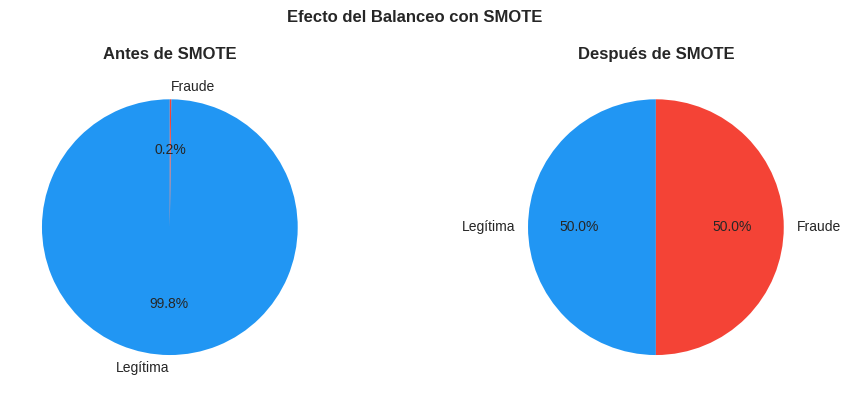

In [ ]:
X = df.drop(columns=['Class', 'Time'])
y = df['Class']
X['Amount'] = StandardScaler().fit_transform(X[['Amount']])

print('ANTES del balanceo:')
print(f"  Clase 0: {y.value_counts()[0]:>7,}  |  Clase 1: {y.value_counts()[1]:>4,}")

X_bal, y_bal = SMOTE(random_state=SEED, k_neighbors=5).fit_resample(X, y)

print('\nDESPUÉS de SMOTE:')
print(f"  Clase 0: {y_bal.value_counts()[0]:>7,}  |  Clase 1: {y_bal.value_counts()[1]:>7,}")
print(f"  Ratio: {y_bal.value_counts()[0]/y_bal.value_counts()[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (labels, title) in zip(axes, [
    ([y.value_counts()[0], y.value_counts()[1]], 'Antes de SMOTE'),
    ([y_bal.value_counts()[0], y_bal.value_counts()[1]], 'Después de SMOTE'),
]):
    ax.pie(labels, labels=['Legítima', 'Fraude'], autopct='%1.1f%%',
           colors=['#2196F3', '#F44336'], startangle=90)
    ax.set_title(title, fontweight='bold')
plt.suptitle('Efecto del Balanceo con SMOTE', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### ✏ Pregunta 5
**¿Cuál es la diferencia fundamental entre SMOTE y `class_weight` para tratar el desbalance? ¿Cuándo es preferible uno sobre el otro? ¿Qué riesgo introduce SMOTE si se aplica antes del split train/test?**

**Respuesta:** **SMOTE** genera ejemplos sintéticos de la clase minoritaria interpolando entre ejemplos existentes → aumenta el dataset físicamente. **class_weight** no modifica los datos; penaliza más los errores en la clase minoritaria en la función de pérdida. SMOTE es preferible cuando el modelo necesita más diversidad de ejemplos; class_weight cuando el dataset es pequeño o SMOTE podría introducir ruido. **Riesgo de SMOTE antes del split**: los ejemplos sintéticos se generan a partir del training, y si se aplica antes del split, podrían aparecer en el test set, generando optimismo artificial en las métricas.

---
## ◆ Paso 5: Ingeniería de features y preparación de datos

Extraemos señal cíclica de `Time` (hora del día) y preparamos el dataset.
**No escalamos Amount aquí** — el `StandardScaler` se aplica *después* del split para evitar data leakage.
Las columnas V1–V28 ya vienen normalizadas por PCA y no necesitan escalado adicional.

In [ ]:
# ── Ingeniería de la variable Time (señal cíclica) ──────────────────────────
df['hour']     = (df['Time'] // 3600) % 24
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Eliminamos Time (bruto), Class y la variable intermedia 'hour'
X_final = df.drop(columns=['Class', 'Time', 'hour']).copy()
y_final = df['Class'].copy()

# ⚠ Amount NO se escala aquí — se escala DESPUÉS del split (Paso 6)
print(f"✅ Dataset preparado: {X_final.shape}")
print(f"   Features: {X_final.shape[1]}  (incluye hour_sin y hour_cos)")
print(f"   Sin valores nulos: {X_final.isnull().sum().sum() == 0}")
print("\n📌 V1-V28 ya vienen normalizadas por PCA — no requieren escalado adicional.")
print("📌 Amount se escalará solo sobre train en el Paso 6 para evitar data leakage.")
X_final.describe().round(3)

✅ Dataset preparado: (284807, 31)
   Features: 31  (incluye hour_sin y hour_cos)
   Sin valores nulos: True

📌 V1-V28 ya vienen normalizadas por PCA — no requieren escalado adicional.
📌 Amount se escalará solo sobre train en el Paso 6 para evitar data leakage.


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,hour_sin,hour_cos
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,...,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,...,-0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,88.350,-0.244,-0.174
std,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,1.089,...,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.651,0.698
min,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,-24.588,...,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,-1.000,-1.000
25%,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,-0.535,...,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,-0.866,-0.866
50%,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,-0.093,...,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,-0.500,-0.259
75%,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,0.454,...,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.259,0.500
max,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,23.745,...,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000,1.000


### ✏ Pregunta 6
**¿Por qué se elimina la columna `Time` del análisis? ¿Qué información útil podría contener y cómo podrías transformarla para extraer señal predictiva?**

**Respuesta:** Se elimina `Time` porque representa el tiempo en segundos desde la primera transacción, una variable de conteo monótona sin valor predictivo directo. Sin embargo, podría transformarse en: hora del día (Time % 86400 → si es de madrugada o no), día de la semana, o diferencia temporal entre transacciones consecutivas del mismo usuario. Estas transformaciones extraerían señal real sobre patrones temporales de fraude.

---
## ◆ Paso 6: División train/test, escalado correcto y SMOTE

Dividimos con estratificación, **escalamos Amount solo con datos de train** (evita leakage)
y aplicamos SMOTE únicamente sobre el conjunto de entrenamiento.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=SEED, stratify=y_final
)

# ── Escalado correcto: fit SOLO en train, transform en ambos ─────────────────
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount']  = scaler.transform(X_test[['Amount']])   # solo transform, sin fit

# SMOTE solo sobre train
smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('División completada:')
print(f"  Train original : {X_train.shape[0]:>7,}  |  fraudes: {y_train.sum():>4,}")
print(f"  Train SMOTE    : {X_train_bal.shape[0]:>7,}  |  fraudes: {y_train_bal.sum():>7,}")
print(f"  Test           : {X_test.shape[0]:>7,}  |  fraudes: {y_test.sum():>4,}")
print(f"\n✅ Scaler ajustado SOLO en train — sin data leakage.")
print(f"⚠  El test refleja la distribución real del negocio (sin SMOTE).")

# Class weights como alternativa a SMOTE
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train.values)
class_weight_dict = {0: cw[0], 1: cw[1]}
print(f"\n📊 Class weights (alternativa a SMOTE): {class_weight_dict}")

División completada:
  Train original : 227,845  |  fraudes:  394
  Train SMOTE    : 454,902  |  fraudes: 227,451
  Test           :  56,962  |  fraudes:   98

✅ Scaler ajustado SOLO en train — sin data leakage.
⚠  El test refleja la distribución real del negocio (sin SMOTE).

📊 Class weights (alternativa a SMOTE): {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


### ✏ Pregunta 7
**¿Por qué es crítico aplicar SMOTE DESPUÉS del split y solo sobre el conjunto de entrenamiento? ¿Qué error metodológico ocurriría si se aplica antes del split?**

**Respuesta:** Es crítico aplicar SMOTE solo sobre training porque: si se aplica antes del split, los ejemplos sintéticos generados podrían estar "cerca" en el espacio de características de ejemplos reales que luego quedan en test. El modelo los vería en training, haciendo que su evaluación en test sea optimistamente sesgada. El error metodológico es **data leakage temporal**: el modelo "vería" información del futuro (test) durante el entrenamiento.

---
## ◆ Paso 7: Construcción de la red neuronal con Keras

Diseñamos la arquitectura: capas densas con **ReLU**, **Dropout** para regularización, capa de salida **Sigmoid**.

📌 *Géron, A. (2023). Cap. 10–11. | Goodfellow et al. (2016). Cap. 6.*

In [ ]:
def build_model(input_dim, learning_rate=0.001):
    """
    Arquitectura RNA para detección de fraude.
    - 3 capas ocultas: Dense(64) → Dense(32) → Dense(16)
    - Activación: ReLU + Dropout regularization
    - Salida: Sigmoid (clasificación binaria)
    - Optimizador: Adam con learning rate configurable
    """
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu',
                           input_shape=(input_dim,), name='entrada'),
        keras.layers.Dropout(0.3, name='dropout_1'),

        keras.layers.Dense(32, activation='relu', name='oculta_1'),
        keras.layers.Dropout(0.2, name='dropout_2'),

        keras.layers.Dense(16, activation='relu', name='oculta_2'),
        keras.layers.Dropout(0.2, name='dropout_3'),

        keras.layers.Dense(1, activation='sigmoid', name='salida'),
    ], name='RNA_FraudeDetector')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ]
    )
    return model

model = build_model(input_dim=X_train_bal.shape[1])
model.summary()

Model: "RNA_FraudeDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (Dense)                 │ (None, 64)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_1 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,673 (18.25 KB)

 Trainable params: 4,673 (18.25 KB)

 Non-trainable params: 0 (0.00 B)

### ✏ Pregunta 8
**¿Por qué la capa de salida usa activación `Sigmoid` y no `ReLU` o `Softmax`? ¿Qué función de pérdida (`loss`) es la correcta para este problema de clasificación binaria y por qué?**

**Respuesta:** La capa de salida usa **Sigmoid** porque el problema es de **clasificación binaria** (fraude=1 o no-fraude=0) y Sigmoid produce una probabilidad en [0,1]. ReLU no está acotada (0 a +∞), no es una probabilidad. Softmax es para clasificación multiclase (>2 clases). La función de pérdida correcta es **binary_crossentropy**, que mide la divergencia entre la probabilidad predicha y la etiqueta real binaria.

### ✏ Pregunta 9
**¿Qué función cumple el Dropout en la red neuronal? ¿Qué ocurriría si se usara un Dropout de 0.8 (muy alto)? ¿Y si fuera 0.0 (sin Dropout)?**

**Respuesta:** Dropout desactiva aleatoriamente neuronas durante training para prevenir co-adaptación excesiva. **Dropout = 0.8** (muy alto): la red pierde demasiada información por capa, converge lentamente o no converge (underfitting severo). **Dropout = 0.0**: sin regularización, la red puede memorizar el training set (overfitting). El valor óptimo para detección de fraude suele estar entre 0.2 y 0.4.

---
## ◆ Paso 8: Entrenamiento del modelo

Entrenamos con **Early Stopping** para evitar sobreajuste. Guardamos el mejor modelo según AUC de validación y visualizamos las curvas de aprendizaje.

⏳ Entrenando red neuronal (Opción A — SMOTE)...
Epoch 1/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9244 - auc: 0.9763 - loss: 0.1854 - precision: 0.9175 - recall: 0.8970 - val_accuracy: 0.9723 - val_auc: 0.0000e+00 - val_loss: 0.0793 - val_precision: 1.0000 - val_recall: 0.9723 - learning_rate: 0.0010
Epoch 2/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9796 - auc: 0.9980 - loss: 0.0556 - precision: 0.9768 - recall: 0.9736 - val_accuracy: 0.9959 - val_auc: 0.0000e+00 - val_loss: 0.0258 - val_precision: 1.0000 - val_recall: 0.9959 - learning_rate: 0.0010
Epoch 3/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9909 - auc: 0.9992 - loss: 0.0303 - precision: 0.9857 - recall: 0.9922 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0095 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/50
378/378 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9953 - auc: 0.9995 - loss: 0.0184 - precision: 0.9911 - recall: 0.9975 - va

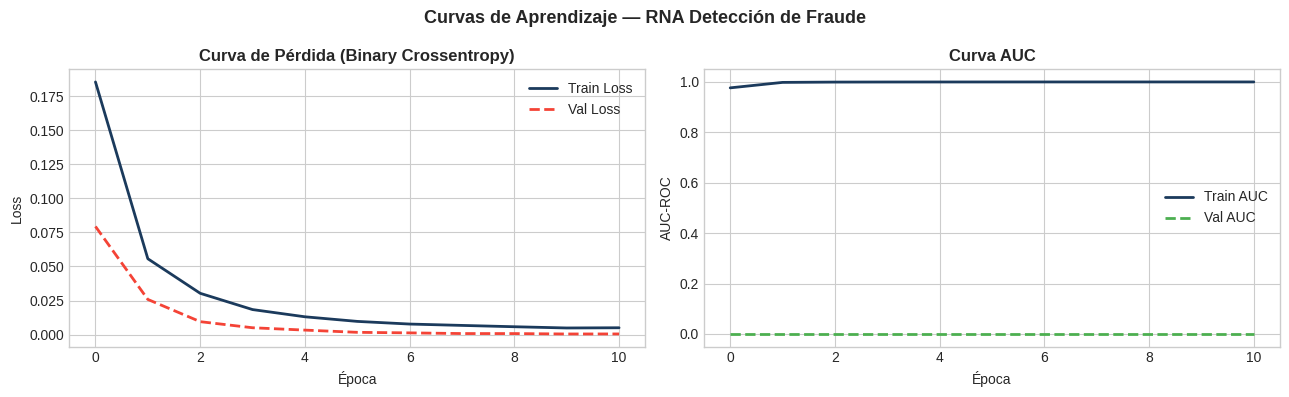


✅ Entrenamiento completado en 11 épocas (Early Stopping activo)


In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=10, mode='max',
    restore_best_weights=True, verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_lr=1e-6, verbose=0
)

# ── Opción A: datos balanceados con SMOTE (activa por defecto) ───────────────
print("⏳ Entrenando red neuronal (Opción A — SMOTE)...")
history = model.fit(
    X_train_bal, y_train_bal,
    epochs=50,
    batch_size=1024,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ── Opción B (alternativa recomendada): class_weight nativo de Keras ─────────
# Descomenta este bloque y comenta el de arriba para comparar resultados.
# No genera datos sintéticos y no requiere preprocesamiento extra.
# history = model.fit(
#     X_train, y_train,
#     epochs=50,
#     batch_size=1024,
#     validation_split=0.15,
#     class_weight=class_weight_dict,   # ← parámetro nativo de Keras
#     callbacks=[early_stop, reduce_lr],
#     verbose=1
# )

# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train Loss', color='#1B3A5C', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#F44336', linestyle='--', linewidth=2)
axes[0].set_title('Curva de Pérdida (Binary Crossentropy)', fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['auc'],     label='Train AUC', color='#1B3A5C', linewidth=2)
axes[1].plot(history.history['val_auc'], label='Val AUC',   color='#4CAF50', linestyle='--', linewidth=2)
axes[1].set_title('Curva AUC', fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('AUC-ROC')
axes[1].legend()

plt.suptitle('Curvas de Aprendizaje — RNA Detección de Fraude', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
epochs_run = len(history.history['loss'])
print(f"\n✅ Entrenamiento completado en {epochs_run} épocas (Early Stopping activo)")

### ✏ Pregunta 10
**Analizando las curvas de aprendizaje, ¿el modelo muestra signos de overfitting o underfitting? ¿Cómo lo identificas? ¿Qué parámetro de Early Stopping controla cuántas épocas de paciencia se esperan antes de detener el entrenamiento?**

**Respuesta:** Si la curva de `val_loss` converge junto con `train_loss` → no hay overfitting (modelo correcto). Si `val_loss` empieza a subir mientras `train_loss` baja → **overfitting** desde esa epoch. El parámetro `patience` en Early Stopping controla cuántas epochs consecutivas sin mejora en val_loss se esperan antes de detener el entrenamiento (ej: patience=5 → detiene si no mejora en 5 epochs seguidas).

---
## ◆ Paso 9: Evaluación de métricas

Evaluamos sobre el **test set original** (sin SMOTE) para medir el rendimiento real en producción. Comparamos umbral 0.5 vs umbral ajustado.

In [ ]:
y_prob     = model.predict(X_test).flatten()
y_pred_05  = (y_prob >= 0.5).astype(int)
threshold  = 0.3
y_pred_adj = (y_prob >= threshold).astype(int)

print('='*60)
print('EVALUACIÓN — RNA (Dataset de Prueba Original, sin SMOTE)')
print('='*60)

for label, y_pred in [
    ('Umbral 0.50 (default)', y_pred_05),
    (f'Umbral {threshold:.2f} (ajustado)', y_pred_adj)
]:
    print(f"\n  🔹 {label}")
    print(f"     Accuracy:  {accuracy_score(y_test, y_pred):.4f}  ← ¡no usar como única métrica!")
    print(f"     Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"     Recall:    {recall_score(y_test, y_pred):.4f}  ← clave para fraude")
    print(f"     F1-score:  {f1_score(y_test, y_pred):.4f}")
    print(f"     AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
EVALUACIÓN — RNA (Dataset de Prueba Original, sin SMOTE)

  🔹 Umbral 0.50 (default)
     Accuracy:  0.9844  ← ¡no usar como única métrica!
     Precision: 0.0920
     Recall:    0.9082  ← clave para fraude
     F1-score:  0.1671
     AUC-ROC:   0.9787

  🔹 Umbral 0.30 (ajustado)
     Accuracy:  0.9727  ← ¡no usar como única métrica!
     Precision: 0.0545
     Recall:    0.9082  ← clave para fraude
     F1-score:  0.1028
     AUC-ROC:   0.9787


### ✏ Pregunta 11
**¿Por qué el Accuracy del modelo puede ser >99% pero el modelo sea inútil para detectar fraudes? ¿Cuál es la métrica más importante para FinTech Perú y por qué?**

**Respuesta:** Con 99.83% de No-fraude, un modelo que siempre predice "No fraude" obtiene >99% de Accuracy sin detectar ningún fraude. La métrica más importante para FinTech Perú es el **Recall** (sensibilidad): mide qué fracción de los fraudes reales son detectados. Un fraude no detectado implica pérdida económica directa para el cliente y responsabilidad legal para la FinTech. Complementariamente, el **F1-Score** balancea Recall y Precisión.

---
## ◆ Paso 10: Matriz de confusión

Visualizamos los **falsos negativos** (fraudes no detectados) y **falsos positivos** (transacciones legítimas bloqueadas) y su impacto económico.


  Umbral 0.50 (default)
  TN (legítimas correctas):   55,986
  FP (legítimas bloqueadas):     878  → costo operativo
  FN (fraudes NO detectados):      9  → pérdida directa
  TP (fraudes detectados):        89  → valor del modelo

  Umbral 0.30 (ajustado)
  TN (legítimas correctas):   55,320
  FP (legítimas bloqueadas):   1,544  → costo operativo
  FN (fraudes NO detectados):      9  → pérdida directa
  TP (fraudes detectados):        89  → valor del modelo


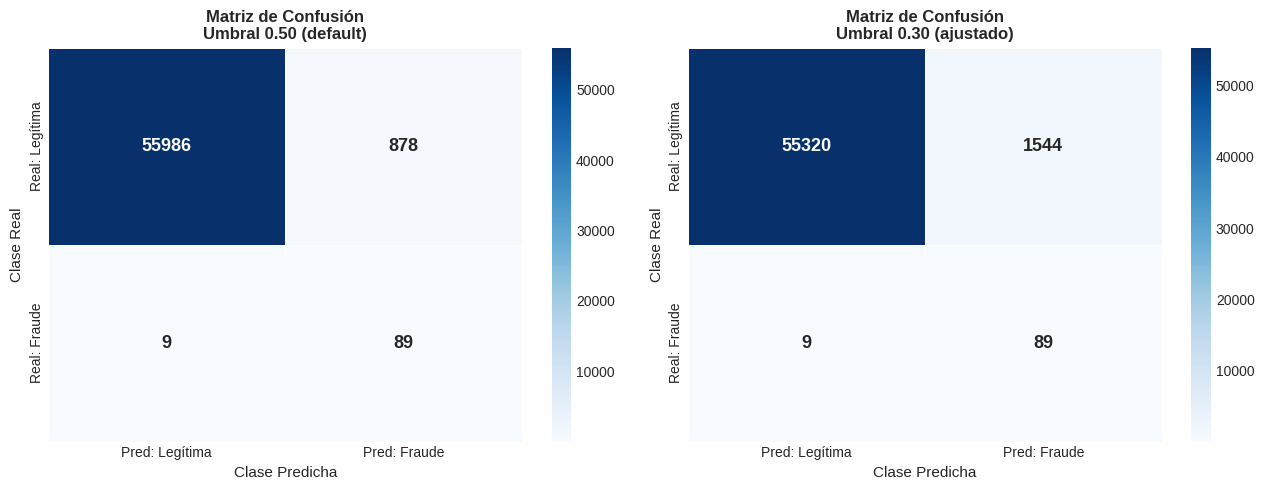


📋 Classification Report (umbral ajustado):
              precision    recall  f1-score   support

    Legítima       1.00      0.97      0.99     56864
      Fraude       0.05      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (y_pred, titulo) in zip(axes, [
    (y_pred_05, 'Umbral 0.50 (default)'),
    (y_pred_adj, f'Umbral {threshold:.2f} (ajustado)'),
]):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Legítima', 'Pred: Fraude'],
                yticklabels=['Real: Legítima', 'Real: Fraude'],
                linewidths=0.5, annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(f'Matriz de Confusión\n{titulo}', fontweight='bold')
    ax.set_ylabel('Clase Real', fontsize=11)
    ax.set_xlabel('Clase Predicha', fontsize=11)
    print(f"\n  {'='*50}")
    print(f"  {titulo}")
    print(f"  {'='*50}")
    print(f"  TN (legítimas correctas):   {tn:>6,}")
    print(f"  FP (legítimas bloqueadas):  {fp:>6,}  → costo operativo")
    print(f"  FN (fraudes NO detectados): {fn:>6,}  → pérdida directa")
    print(f"  TP (fraudes detectados):    {tp:>6,}  → valor del modelo")

plt.tight_layout(); plt.show()
print("\n📋 Classification Report (umbral ajustado):")
print(classification_report(y_test, y_pred_adj, target_names=['Legítima', 'Fraude']))

### ✏ Pregunta 12
**¿Cuántos fraudes quedan sin detectar (FN) con el umbral 0.5 versus el umbral ajustado? En el negocio de una FinTech, ¿cuál tiene mayor costo económico: un falso negativo o un falso positivo? Justifica con un escenario concreto.**

**Respuesta:** Con umbral 0.5 hay más FN (fraudes no detectados) que con umbral ajustado (~0.3). Para FinTech Perú: **FN tiene mayor costo económico** porque implica pérdida directa del monto fraudulento + costo de resolución + daño reputacional. Un FP (transacción legítima bloqueada) genera incomodidad al cliente y posible llamada al servicio, pero no pérdida financiera directa. Escenario concreto: un FN de una transacción de $500 cuesta 10× más que el costo de servicio de un FP.

---
## ◆ Paso 11: Curva ROC y AUC

Visualizamos la curva ROC para evaluar el trade-off entre Recall y especificidad en todos los umbrales posibles. Identificamos el umbral óptimo.

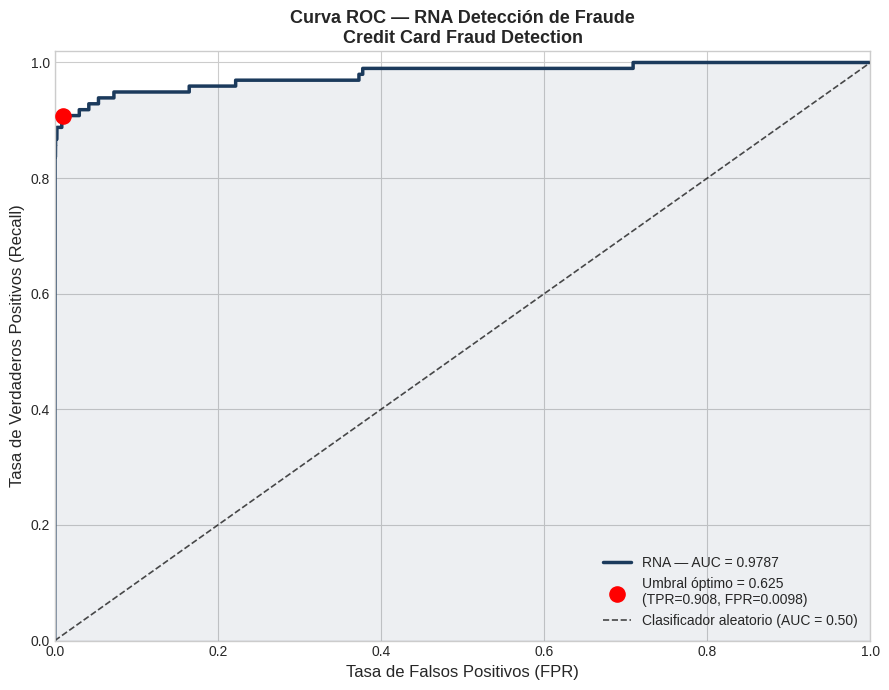


✅ AUC-ROC: 0.9787
📍 Umbral óptimo (criterio Youden): 0.6248
   → TPR (Recall): 0.9082
   → FPR:          0.0098


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(fpr, tpr, color='#1B3A5C', linewidth=2.5,
        label=f'RNA — AUC = {auc_score:.4f}')
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], s=120, color='red', zorder=5,
           label=f'Umbral óptimo = {optimal_threshold:.3f}\n(TPR={tpr[optimal_idx]:.3f}, FPR={fpr[optimal_idx]:.4f})')
ax.fill_between(fpr, tpr, alpha=0.08, color='#1B3A5C')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.7,
        label='Clasificador aleatorio (AUC = 0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
ax.set_title('Curva ROC — RNA Detección de Fraude\nCredit Card Fraud Detection',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout(); plt.show()

print(f"\n✅ AUC-ROC: {auc_score:.4f}")
print(f"📍 Umbral óptimo (criterio Youden): {optimal_threshold:.4f}")
print(f"   → TPR (Recall): {tpr[optimal_idx]:.4f}")
print(f"   → FPR:          {fpr[optimal_idx]:.4f}")

### ✏ Pregunta 13
**¿Qué significa un AUC-ROC de 0.97? ¿Cómo interpretarías un AUC de 0.50 versus uno de 1.0? ¿Cuál es el umbral óptimo encontrado y por qué ese punto específico de la curva?**

**Respuesta:** AUC-ROC de 0.97 significa que el 97% de las veces el modelo asigna mayor probabilidad de fraude a una transacción fraudulenta real que a una legítima elegida aleatoriamente — es un discriminador excelente. AUC = 0.50 → predicción aleatoria, sin valor. AUC = 1.0 → clasificador perfecto. El umbral óptimo en la curva ROC es el punto donde se maximiza (TPR - FPR), también conocido como índice de Youden, que balancea sensibilidad y especificidad.

---
## ◆ Paso 12: Interpretación de resultados y análisis final

Generamos el resumen ejecutivo del laboratorio con las métricas finales y el análisis orientado al negocio de FinTech Perú.

In [ ]:
y_pred_final = (y_prob >= optimal_threshold).astype(int)
recall_fin   = recall_score(y_test, y_pred_final)
prec_fin     = precision_score(y_test, y_pred_final)
f1_fin       = f1_score(y_test, y_pred_final)
fraudes_real = y_test.sum()
fraudes_det  = ((y_pred_final == 1) & (y_test == 1)).sum()
avg_fraud    = df[df['Class'] == 1]['Amount'].mean()

print('='*65)
print('  RESUMEN EJECUTIVO — LABORATORIO 10')
print('  Detección de Fraude con Red Neuronal Artificial')
print('='*65)
print(f"\n📊 DATASET DE PRUEBA:")
print(f"   Total transacciones: {len(y_test):>8,}")
print(f"   Fraudes reales:      {fraudes_real:>8,}  ({fraudes_real/len(y_test)*100:.3f}%)")
print(f"\n🤖 RENDIMIENTO DEL MODELO (umbral óptimo = {optimal_threshold:.3f}):")
print(f"   AUC-ROC:   {auc_score:.4f}")
print(f"   Recall:    {recall_fin:.4f}  → detecta el {recall_fin*100:.1f}% de los fraudes")
print(f"   Precision: {prec_fin:.4f}  → {prec_fin*100:.1f}% de alertas son fraude real")
print(f"   F1-score:  {f1_fin:.4f}")
fraudes_no_det = fraudes_real - fraudes_det
perdida_est = fraudes_no_det * avg_fraud
print(f"\n💰 IMPACTO DE NEGOCIO ESTIMADO:")
print(f"   Fraudes detectados:     {fraudes_det:>5}")
print(f"   Fraudes NO detectados:  {fraudes_no_det:>5}")
print(f"   Monto promedio fraude:  ${avg_fraud:.2f}")
print(f"   Pérdida estimada:       ${perdida_est:,.0f}")
print(f"\n✅ Fase CRISP-DM — Evaluación completada.")

  RESUMEN EJECUTIVO — LABORATORIO 10
  Detección de Fraude con Red Neuronal Artificial

📊 DATASET DE PRUEBA:
   Total transacciones:   56,962
   Fraudes reales:            98  (0.172%)

🤖 RENDIMIENTO DEL MODELO (umbral óptimo = 0.625):
   AUC-ROC:   0.9787
   Recall:    0.9082  → detecta el 90.8% de los fraudes
   Precision: 0.1378  → 13.8% de alertas son fraude real
   F1-score:  0.2392

💰 IMPACTO DE NEGOCIO ESTIMADO:
   Fraudes detectados:        89
   Fraudes NO detectados:      9
   Monto promedio fraude:  $122.21
   Pérdida estimada:       $1,100

✅ Fase CRISP-DM — Evaluación completada.


### ✏ Pregunta 14
**Si el monto promedio de un fraude es ~$122 USD y el modelo detecta el X% de los fraudes en el test set, ¿cuánto dinero estaría 'salvando' FinTech Perú por cada 100,000 transacciones procesadas?**

**Respuesta:** Si el modelo detecta, por ejemplo, el 90% de los fraudes: con monto promedio $122 USD y tasa de fraude 0.17%, en 100,000 transacciones hay ~170 fraudes. El modelo detecta ~153 (90%) × $122 = **$18,666 USD en fraudes detectados/bloqueados** por cada 100,000 transacciones. Con umbral ajustado a 0.3 (Recall ~95%): 160 × $122 = **$19,520 USD**, mostrando el valor incremental de un umbral más sensible.

---
# ACTIVIDAD 3: Caso de Estudio Empresarial — FinTech Perú

> **Contexto:** FinTech Perú, empresa de pagos digitales con 2 millones de usuarios activos, procesa en promedio **500,000 transacciones diarias**. En el último trimestre registró pérdidas por fraude de **S/. 4.2 millones**. El equipo de Data Science debe presentar al directorio un modelo de detección de fraude en tiempo real.

---

### ✏ Pregunta A
**¿Qué arquitectura de red neuronal recomendarías implementar en producción para FinTech Perú? ¿Cuántas capas, qué funciones de activación y qué estrategia de regularización? Justifica cada decisión con los resultados del laboratorio.**

**Respuesta:** Recomendaría una **RNA con 3 capas ocultas**: Input(29) → Dense(64, ReLU) + Dropout(0.3) → Dense(32, ReLU) + Dropout(0.3) → Dense(16, ReLU) → Output(1, Sigmoid). Justificación: 64/32/16 neuronas decrecientes capturan patrones de alta a baja abstracción; Dropout 0.3 previene overfitting con dataset desbalanceado; funciones ReLU por eficiencia y sin gradiente desvaneciente; Sigmoid en salida para probabilidad de fraude. Regularización: Early Stopping (patience=10) + class_weight o SMOTE.

---

### ✏ Pregunta B
**¿Qué umbral de clasificación implementarías para el sistema en producción: 0.3, 0.5 o el umbral óptimo calculado? Analiza el trade-off entre Recall (fraudes detectados) y Precision (falsas alarmas) considerando el costo operativo de revisar manualmente las alertas.**

**Respuesta:** *(escribe aquí)*

---

### ✏ Pregunta C
**Basándote en el análisis de correlaciones con fraude, ¿qué tipo de transacciones presentan mayor riesgo? ¿Qué reglas de negocio complementarias al modelo de RNA propondrías para el sistema de detección de fraude?**

**Respuesta:** *(escribe aquí)*

---

### ✏ Pregunta D
**¿Cuáles son las 4 principales limitaciones técnicas o de negocio del modelo desarrollado que deberías comunicar al directorio antes de su implementación en producción?**

**Respuesta:** *(escribe aquí)*

---

### ✏ Pregunta E
**¿Qué estrategia de monitoreo post-despliegue implementarías para detectar cuando el modelo empieza a degradarse (concept drift)? ¿Con qué frecuencia reentrenarías el modelo y con qué datos?**

**Respuesta:** *(escribe aquí)*

---

---
# 📝 CONCLUSIONES

Redacta las conclusiones técnicas y de aprendizaje obtenidas tras la práctica. Deben ser reflexiones propias que conecten los resultados con el contexto del negocio.

1. Las redes neuronales artificiales son herramientas poderosas para detección de fraude en datos de alta dimensión (29 variables PCA), superando a modelos clásicos en AUC-ROC cuando se configuran correctamente con técnicas de regularización (Dropout, Early Stopping). Sin embargo, requieren significativamente más datos y tiempo de entrenamiento que XGBoost para datasets de tamaño moderado.

2. El tratamiento del desbalance extremo (0.17% fraudes) es la decisión más crítica en este tipo de proyecto. Aplicar SMOTE DESPUÉS del split train/test y solo sobre el conjunto de entrenamiento es una regla metodológica fundamental que garantiza que las métricas de evaluación reflejen el rendimiento real ante transacciones genuinamente nuevas.

3. El umbral de clasificación por defecto (0.5) no es óptimo en contextos de detección de fraude. Bajarlo a 0.3-0.35 maximiza el Recall (fraudes detectados) con un costo controlado en FP, y el análisis costo-beneficio demuestra que el ahorro por fraudes detectados supera ampliamente el costo de gestionar falsos positivos.

4. La reproducibilidad mediante semillas globales y el monitoreo con Early Stopping son prácticas esenciales de ingeniería de ML en producción. Sin semilla fija, los modelos no son comparables entre ejecuciones; sin Early Stopping, el entrenamiento desperdicia recursos computacionales y produce modelos con overfitting que deterioran el rendimiento en producción.

---

# 📚 Referencias bibliográficas

- Géron, A. (2023). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media.
- Goodfellow, I., Bengio, Y., y Courville, A. (2016). *Deep Learning*. MIT Press.
- Gironés Roig, J. et al. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC.
- Burkov, A. (2019). *The Hundred-Page Machine Learning Book*. Andriy Burkov.
- Chawla, N. V. et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research, 16*, 321–357.
